In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification, TrainingArguments, Trainer

c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [3]:
def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(chain.from_iterable([target_idx[idx][:max_len] for idx in range(len(classes))]))
    return Subset(dataset, indices)

train_dataset = datasets.FashionMNIST(root= './datasets', download = True, train = True)
test_dataset = datasets.FashionMNIST(root= './datasets', download = True, train = False)

In [4]:
classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

print(classes)
print(class_to_idx)

subset_train_dataset = subset_sampler(dataset = train_dataset, 
classes = train_dataset.classes, 
max_len = 1000)

subset_test_dataset = subset_sampler(dataset = test_dataset,
classes = test_dataset.classes,
max_len = 100)

print(len(subset_train_dataset))
print(len(subset_test_dataset))

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
10000
1000


c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


In [5]:
image_processor = AutoImageProcessor.from_pretrained(pretrained_model_name_or_path="google/vit-base-patch16-224-in21k")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size = (image_processor.size['height'],
                                 image_processor.size['width'])),
    transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
    transforms.Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
])

print(image_processor.size)
print(image_processor.image_mean)
print(image_processor.image_std)

c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


{'height': 224, 'width': 224}
[0.5, 0.5, 0.5]
[0.5, 0.5, 0.5]


In [6]:
from torch.utils.data import DataLoader

def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {'pixel_values': pixel_values, 'labels': labels}

train_dataloader = DataLoader(subset_train_dataset, batch_size=32, shuffle=True, collate_fn=lambda x: collator(x, transform), drop_last=True)
valid_dataloader = DataLoader(subset_test_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: collator(x, transform), drop_last=True)

batch = next(iter(train_dataloader))
for key, value in batch.items():
    print(key, value.shape)

pixel_values torch.Size([32, 3, 224, 224])
labels torch.Size([32])


In [7]:
model = ViTForImageClassification.from_pretrained(pretrained_model_name_or_path="google/vit-base-patch16-224-in21k", num_labels=len(classes), id2label = {idx: label for label, idx in class_to_idx.items()}, label2id = class_to_idx, ignore_mismatched_sizes = True)

print(model.classifier)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Linear(in_features=768, out_features=10, bias=True)


In [8]:
print(model.vit.embeddings)

batch = next(iter(train_dataloader))
print(batch['pixel_values'].shape)
print(model.vit.embeddings.patch_embeddings(batch['pixel_values']).shape)
print(model.vit.embeddings(batch['pixel_values']).shape)

ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
torch.Size([32, 3, 224, 224])
torch.Size([32, 196, 768])
torch.Size([32, 197, 768])


In [9]:
import evaluate
import numpy as np

def compute_metrics(eval_pred):
    metric = evaluate.load('f1')
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(predictions=predictions, references=labels, average='macro')
    return macro_f1

In [ ]:
def model_init(classes, class_to_idx):
    return ViTForImageClassification.from_pretrained(
        pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
        num_labels=len(classes),
        id2label = {idx: label for label, idx in class_to_idx.items()},
        label2id = class_to_idx,
        ignore_mismatched_sizes = True
    )

args = TrainingArguments(
    output_dir = './model/Vit-FashionMNIST',
    save_strategy = 'epoch',
    evaluation_strategy = 'epoch',
    learning_rate = 1e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 3,
    weight_decay = 0.001,
    load_best_model_at_end = True,
    metric_for_best_model = 'f1',
    logging_dir = 'logs',
    logging_steps = 125,
    remove_unused_columns = False,
    seed = 42)

trainer = Trainer(model_init = lambda x: model_init(classes, class_to_idx),
                  args = args, train_dataset = subset_train_dataset,
                  eval_dataset = subset_test_dataset,
                  data_collator = lambda x: collator(x, transform),
                  compute_metrics = compute_metrics,
                  tokenizer = image_processor)

trainer.train()

c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\accelerate\accelerator.py:457: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None)
  warnings.warn(
c:\Users\KDS23\Documents\17-KDT\17-vision_transformer\.venv-cuda\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task 

{'loss': 1.926, 'learning_rate': 9.600000000000001e-06, 'epoch': 0.2}


  8%|▊         | 250/3125 [01:40<18:58,  2.53it/s]

{'loss': 1.2605, 'learning_rate': 9.200000000000002e-06, 'epoch': 0.4}


 12%|█▏        | 375/3125 [02:29<18:14,  2.51it/s]

...

                                                   
100%|██████████| 3125/3125 [22:05<00:00,  2.51it/s]

{'eval_loss': 0.33210253715515137, 'eval_f1': 0.926895693711025, 'eval_runtime': 14.8608, 'eval_samples_per_second': 67.291, 'eval_steps_per_second': 4.239, 'epoch': 5.0}


100%|██████████| 3125/3125 [22:06<00:00,  2.36it/s]

{'train_runtime': 1326.8819, 'train_samples_per_second': 37.682, 'train_steps_per_second': 2.355, 'train_loss': 0.5068779089355469, 'epoch': 5.0}


TrainOutput(global_step=3125, training_loss=0.5068779089355469, metrics={'train_runtime': 1326.8819, 'train_samples_per_second': 37.682, 'train_steps_per_second': 2.355, 'train_loss': 0.5068779089355469, 'epoch': 5.0})

100%|██████████| 63/63 [00:14<00:00,  4.26it/s]


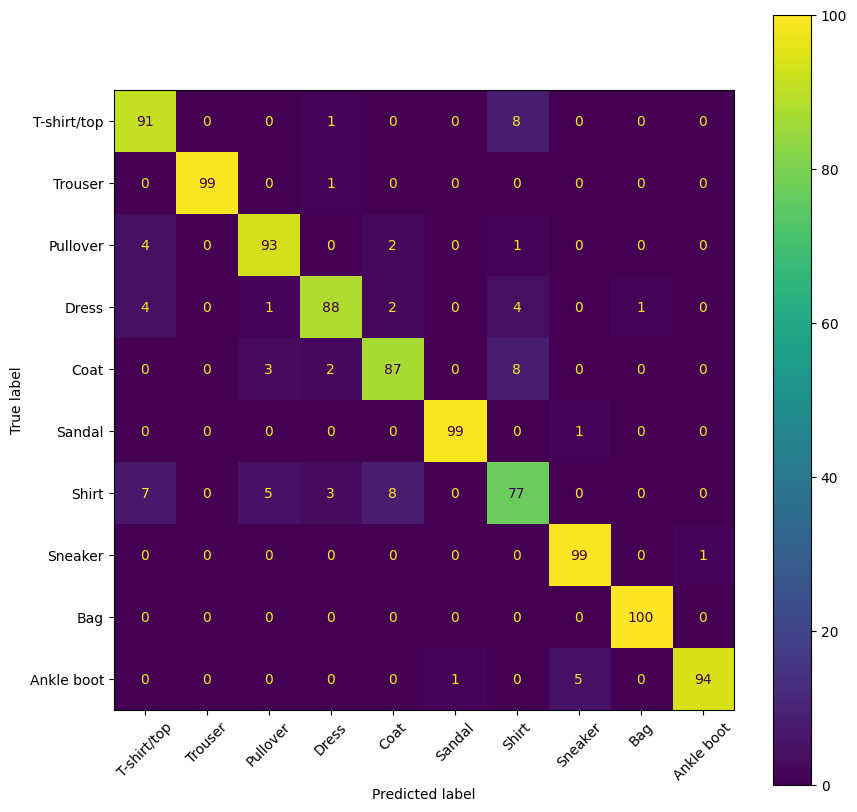

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

outputs = trainer.predict(subset_test_dataset)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)
labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = labels)

_, ax = plt.subplots(figsize = (10,10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()
